***Zakiye Amin***

***810102398***

---

In [56]:
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import re
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, homogeneity_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

***Loading data***

In [2]:
music_df = pd.read_csv('musicLyrics.csv')

---

***Preprocess***

Text data in its raw form is often noisy. Preprocessing helps to clean and standardize the data, making it more suitable for machine learning models. It removes irrelevant characters, reduces word variation, and enhances the overall quality of features extracted from the text.

In [3]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /home/zakiye/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/zakiye/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
print(music_df.columns)

Index(['Lyric'], dtype='object')


In [6]:
def preprocess(text, method):
    text = text.lower()
    text = re.sub(r'\n|\r', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    if method == 'stem':
        words = [PorterStemmer().stem(w) for w in words]
    elif method == 'lemmatize':
        words = [WordNetLemmatizer().lemmatize(w) for w in words]
    return ' '.join(words)

music_df['stemmed_lyrics'] = music_df['Lyric'].apply(lambda x: preprocess(x, method='stem'))
music_df['lemmatized_lyrics'] = music_df['Lyric'].apply(lambda x: preprocess(x, method='lemmatize'))

Steps Implemented in the Code:

    Lowercasing 

    Removing punctuation

    Removing irrelevant characters like \n and \r

    Removing stop words
    
    Stemming & Lemmatization 

Stemming : Reduces words to their root form by chopping off suffixes, often without considering the actual meaning. It is fast and simple but may produce non-dictionary words.

Lemmatization : Converts words to their base form using grammar and context. It produces accurate base forms but it is slower and requires linguistic resources. 


In our project, lemmatization performed better.

---

***Feature Extraction using SentenceTransformers***

Why do we extract features from text? Why isn’t reading the raw text enough?

    Convert text into machine-understandable format

    Focus on meaningful information:

    Reduce dimensionality and complexity

    Improve model performance

In [7]:
pip install sentence_transformers

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

    Transformer Sentence Models and all-MiniLM-L6-v2

Transformer Sentence Models : These models use a special method called Transformer to turn sentences into numbers (vectors). These numbers show the meaning of the sentences so models can understand and compare them.

all-MiniLM-L6-v2 : This is a smaller and faster version of Transformer models. It creates good-quality sentence numbers but uses less memory and runs quicker, making it great for fast tasks or devices with less power.

In [9]:
stemmed_embeddings = model.encode(music_df['stemmed_lyrics'].tolist(), show_progress_bar=True)
lemmatized_embeddings = model.encode(music_df['lemmatized_lyrics'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

---

In [39]:
def print_sample(row_name):
    for cluster_label, group in row_name:
        if len(group) < 2:
            continue 
        print(f"\nCluster {cluster_label}")
        sample = group.sample(2, random_state=42)  
        
        for i, row in enumerate(sample.itertuples(), 1):
            print(f"\nSample {i}:")
            print(row.Lyric[:200], '...')  

***Clustering Methods***

1. K-Means Clustering:

Partitions data into a K clusters by assigning points to the nearest centroid and updating centroids iteratively.

2. DBSCAN:

Groups points based on density, forming clusters where points are close together and marking sparse points as noise.

3. Hierarchical Clustering:

Creates a tree of clusters by either merging or splitting data points based on similarity.

     K-Means + Elbow Method

The Elbow method helps to choose the optimal number of clusters (K) for K-Means clustering. Calculate the Within-Cluster Sum of Squares (WCSS), which measures how compact the clusters are. Look for the "elbow" point on the plot — where the rate of decrease sharply slows down. Choose that K.

- For stemmed embedding:

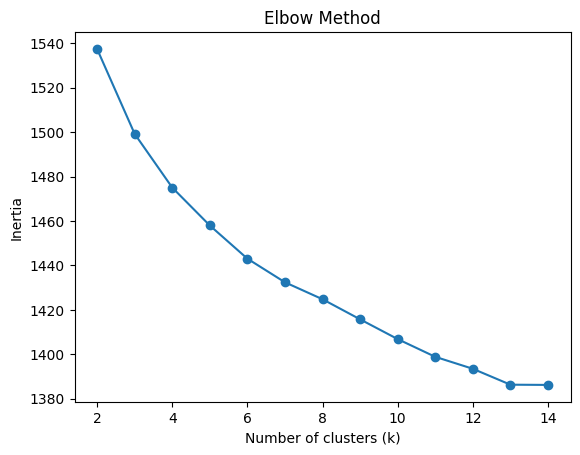

In [10]:
inertia = []
k_range = range(2, 15)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(stemmed_embeddings)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

We choose K = 6 based on plot.

In [11]:
K = 6  
kmeans = KMeans(n_clusters=K, random_state=0)
music_df['stemmed_kmeans_cluster'] = kmeans.fit_predict(stemmed_embeddings)

- For lemmatized embedding:

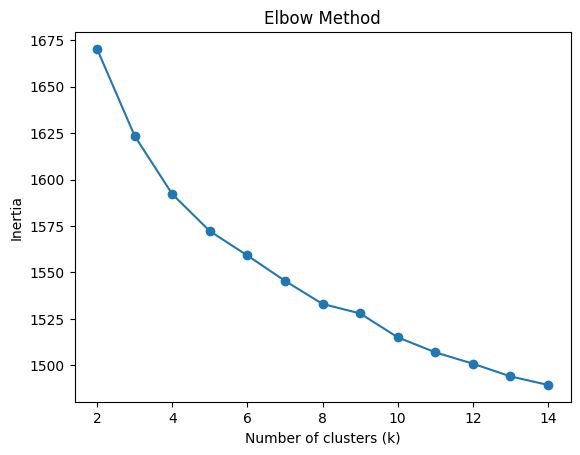

In [12]:
inertia = []
k_range = range(2, 15)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(lemmatized_embeddings)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

We choose K = 4, based on plot.

In [13]:
K = 4 
kmeans = KMeans(n_clusters=K, random_state=0)
music_df['lemmatized_kmeans_cluster'] = kmeans.fit_predict(lemmatized_embeddings)

Sample Lyrics from Each Cluster (Lemmatized KMeans):

In [40]:
lemm_kmeans_clusters = music_df.groupby('lemmatized_kmeans_cluster')
print_sample(lemm_kmeans_clusters )


Cluster 0

Sample 1:
[Verse 1 Kano] Ah, Twentyfour seven Im on this Viagra flow hardest for the longest Niagra flow pass this at your own risk Aha their not finding the Kane But the flows like herpes never go away Creps l ...

Sample 2:
I look into your face No flaws I cant see a trace You the electricity to my heart Whenever I feel down you give me a jump start When your lips leave mine my mouth feels tart So Im going to ask you to  ...

Cluster 1

Sample 1:
My eyes are open, Though Im inside a dream Im laying on the bed, But my soul is running I feel the burning sweat covering my body. My heart beats as hell I cant catch my breath Im waiting for the days ...

Sample 2:
life is a long lived torment haunted by our useless existence the world will still keep decaying when were all in our grave depression live is morbid hell precious? I think not who cares about the fel ...

Cluster 2

Sample 1:
The bus north was a rumbling gray coffin, evidence of my failure, like a tamed and crippled 

    DBSCAN

- For stemmed embedding:

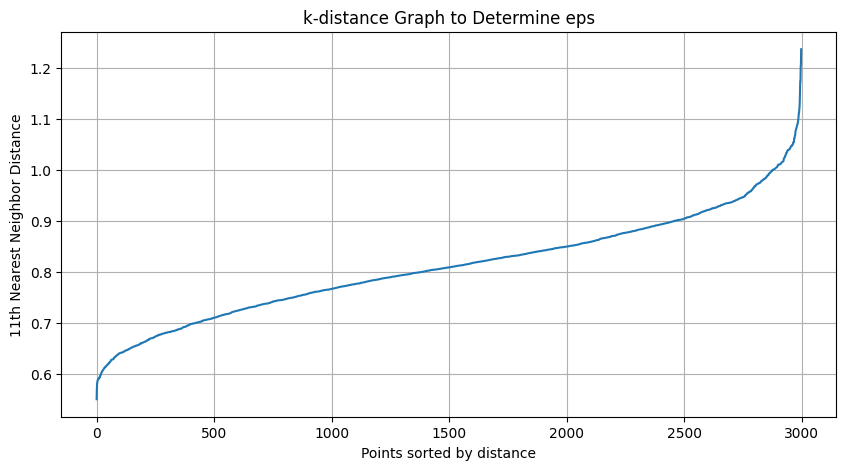

In [57]:
k = 11
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(stemmed_embeddings)
distances, indices = nbrs.kneighbors(stemmed_embeddings)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.ylabel(f"{k}th Nearest Neighbor Distance")
plt.xlabel("Points sorted by distance")
plt.title("k-distance Graph to Determine eps")
plt.grid(True)
plt.show()

The eps based on this plot should be near to 1, but it doesn't work well, so I find proper eps manually.

In [ ]:
X_scaled = StandardScaler().fit_transform(stemmed_embeddings)
dbscan = DBSCAN(eps=0.56, min_samples=12, metric='cosine', algorithm='brute', n_jobs=-1)
music_df['stemmed_dbscan_cluster'] = dbscan.fit_predict(X_scaled)

- For lemmatized embedding:

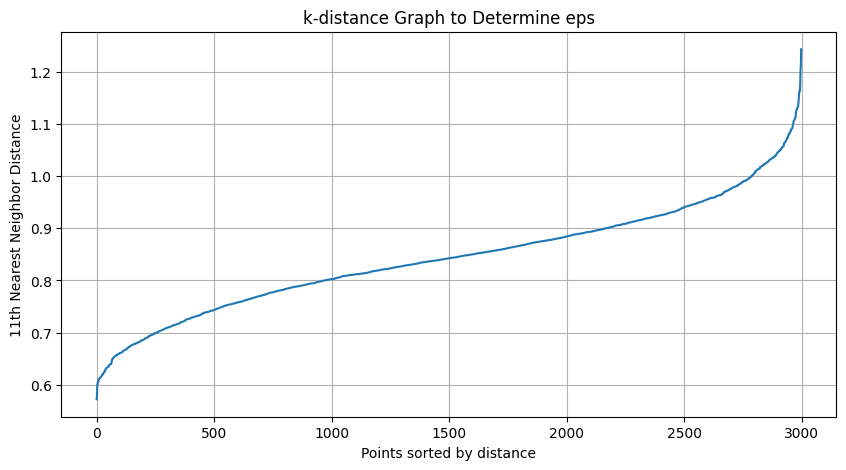

In [68]:
k = 11
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(lemmatized_embeddings)
distances, indices = nbrs.kneighbors(lemmatized_embeddings)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.ylabel(f"{k}th Nearest Neighbor Distance")
plt.xlabel("Points sorted by distance")
plt.title("k-distance Graph to Determine eps")
plt.grid(True)
plt.show()

The eps based on this plot should be near to 1, but it doesn't work well, so I find proper eps manually.

In [63]:
X_scaled = StandardScaler().fit_transform(lemmatized_embeddings)
dbscan = DBSCAN(eps=0.56, min_samples=12, metric='cosine', algorithm='brute', n_jobs=-1)
music_df['lemmatized_dbscan_cluster'] = dbscan.fit_predict(X_scaled)

Sample Lyrics from Each Cluster (Lemmatized DBSCAN):

In [41]:
lemm_dbscan_clusters = music_df.groupby('lemmatized_dbscan_cluster')
print_sample(lemm_dbscan_clusters)


Cluster -1

Sample 1:
I remember back when Magic was all I had Derevi was banned and Venser was bad Islands were what David used And blue was considered abused Joe thought he was big and cool But would always lose like a f ...

Sample 2:
[Intro] Why you so ice cold? They ask me why Im so ice cold [Verse 1] They ask me why Im so ice cold How I got it in my system, this shit in my vision Based freestyle man, a kid spitting Based freesty ...

Cluster 0

Sample 1:
[Hook] Atleast they know its Christmas Eve But tomorrow what will they believe They know its Christmas Eve But tomorrow what will they see [Verse 1] What do they need What do they believe Is it really ...

Sample 2:
Staring upon the grave of my mind Long after I killed Everything dear to me A desperate attempt to Recreate my life Locked in the past I left my self blind Driven backwards to the future Remorseful ab ...

Cluster 1

Sample 1:
[Verse 1] Strange how my heart beats To find myself upon your shore Strange how I still fee

    Hierarchical Clustering

- For stemmed embedding:

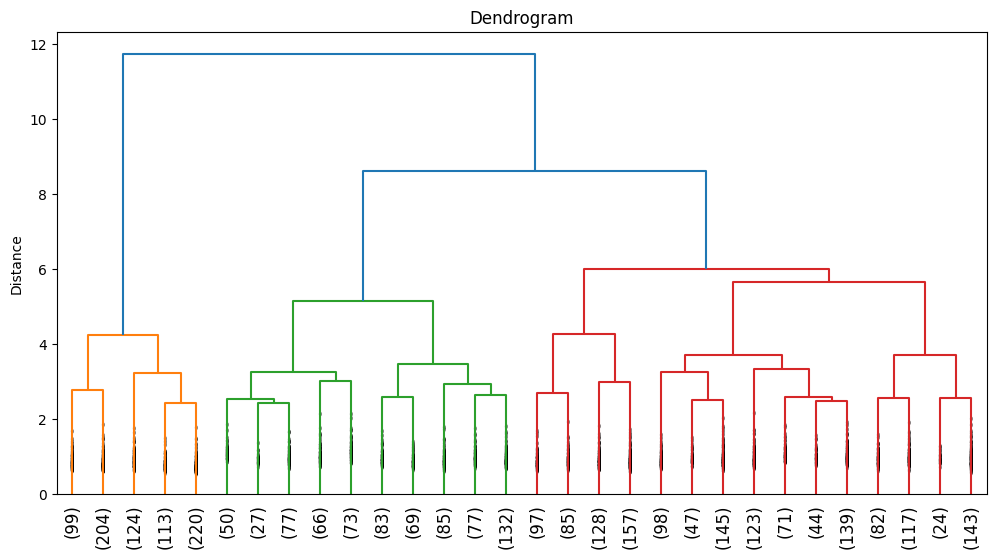

In [46]:
linked = linkage(stemmed_embeddings, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=12., show_contracted=True)
plt.title('Dendrogram')
plt.ylabel('Distance')
plt.show()

We choose num of cluster = 4 based on denogram.

In [48]:
agg = AgglomerativeClustering(n_clusters= 4)
music_df['stemmed_hierarchical_cluster'] = agg.fit_predict(stemmed_embeddings)

- For lemmatized embedding:

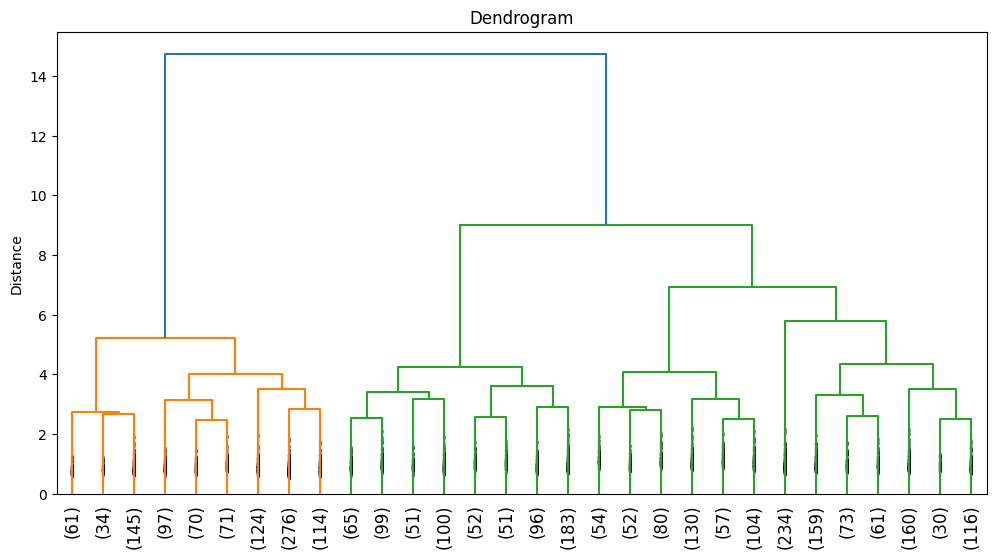

In [47]:
linked = linkage(lemmatized_embeddings, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=12., show_contracted=True)
plt.title('Dendrogram')
plt.ylabel('Distance')
plt.show()

We choose num of cluster = 3 based on denogram.

In [49]:
agg = AgglomerativeClustering(n_clusters= 3)
music_df['lemmatized_hierarchical_cluster'] = agg.fit_predict(lemmatized_embeddings)

Sample Lyrics from Each Cluster (Lemmatized hierarchical):

In [50]:
lemm_hierarchical_clusters = music_df.groupby('lemmatized_hierarchical_cluster')
print_sample(lemm_hierarchical_clusters )


Cluster 0

Sample 1:
Im left standing alone The last killer in the killing field You said goodbye through gunshot fire Im still left here breathing Sold on surviving but whats the cost? You had your one shot and you took  ...

Sample 2:
All exits are closed for me, the only thing Ill ever see is A corridor to the black infinity A taste of supremacy or the deepest void of sanity Parasites of this state of liberty Yeah, I know this fee ...

Cluster 1

Sample 1:
[Intro Stefano] Oohoohoohooh Oohoohoohooh Oohoohoohooh Oohoohoohooh [Verse 1 Stefano] IIII got a fast pass to the front of the line And Im rolling out with some friends of mine I got the Midas Touch w ...

Sample 2:
Prietene, nu te du acolo este slaul psrii morii... Eastern bound to far Carpathia, how the rain it stings my skin Brandys fire and thoughts of hometown fail to quell unrest within Mile on mile the coa ...

Cluster 2

Sample 1:
Take a deep look into the centre of your eyes into the vast dark abyss of your soul Who do y

    Comparing methods

In [51]:
def evaluate_clustering(silhouette_scores, embeddings, labels, method_name=''):
    if len(set(labels)) > 1 and len(set(labels)) < len(labels):
        sil_score = silhouette_score(embeddings, labels)
        silhouette_scores[method_name] = sil_score
        print(f"{method_name} - Silhouette Score: {sil_score:.4f}")
    else:
        silhouette_scores[method_name] = None
        print(f"{method_name} - Silhouette Score: Not applicable")

silhouette_scores = {}

evaluate_clustering(silhouette_scores, stemmed_embeddings, music_df['stemmed_kmeans_cluster'], 'Stemmed KMeans')
evaluate_clustering(silhouette_scores, StandardScaler().fit_transform(stemmed_embeddings), music_df['stemmed_dbscan_cluster'], 'Stemmed DBSCAN')
evaluate_clustering(silhouette_scores, stemmed_embeddings, music_df['stemmed_hierarchical_cluster'], 'Stemmed Hierarchical')
print('\n')
evaluate_clustering(silhouette_scores, lemmatized_embeddings, music_df['lemmatized_kmeans_cluster'], 'Lemmatized KMeans')
evaluate_clustering(silhouette_scores, StandardScaler().fit_transform(lemmatized_embeddings), music_df['lemmatized_dbscan_cluster'], 'Lemmatized DBSCAN')
evaluate_clustering(silhouette_scores, lemmatized_embeddings, music_df['lemmatized_hierarchical_cluster'], 'Lemmatized Hierarchical')

Stemmed KMeans - Silhouette Score: 0.0180
Stemmed DBSCAN - Silhouette Score: -0.0355
Stemmed Hierarchical - Silhouette Score: 0.0095


Lemmatized KMeans - Silhouette Score: 0.0482
Lemmatized DBSCAN - Silhouette Score: -0.0298
Lemmatized Hierarchical - Silhouette Score: 0.0440


Lemmatized KMeans has the highest Silhouette Score, means clusters are more well-defined and separated. KMeans often works well on numerical vector spaces from text embeddings, producing more distinct clusters compared to hierarchical in this case.

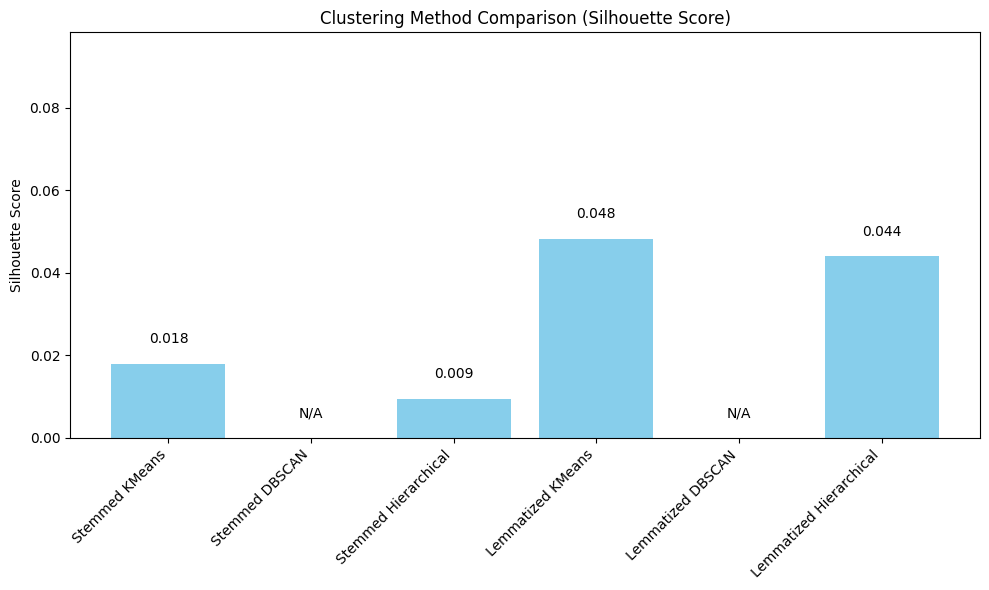

In [52]:
methods = list(silhouette_scores.keys())
scores = [silhouette_scores[m] if silhouette_scores[m] is not None else 0 for m in methods]
colors = ['skyblue' if silhouette_scores[m] is not None else 'lightgray' for m in methods]

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, scores, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Silhouette Score')
plt.title('Clustering Method Comparison (Silhouette Score)')
plt.ylim(0, max(scores) + 0.05)

for bar, score in zip(bars, scores):
    if score > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{score:.3f}', ha='center')
    else:
        plt.text(bar.get_x() + bar.get_width()/2, 0.005, 'N/A', ha='center')

plt.tight_layout()
plt.show()


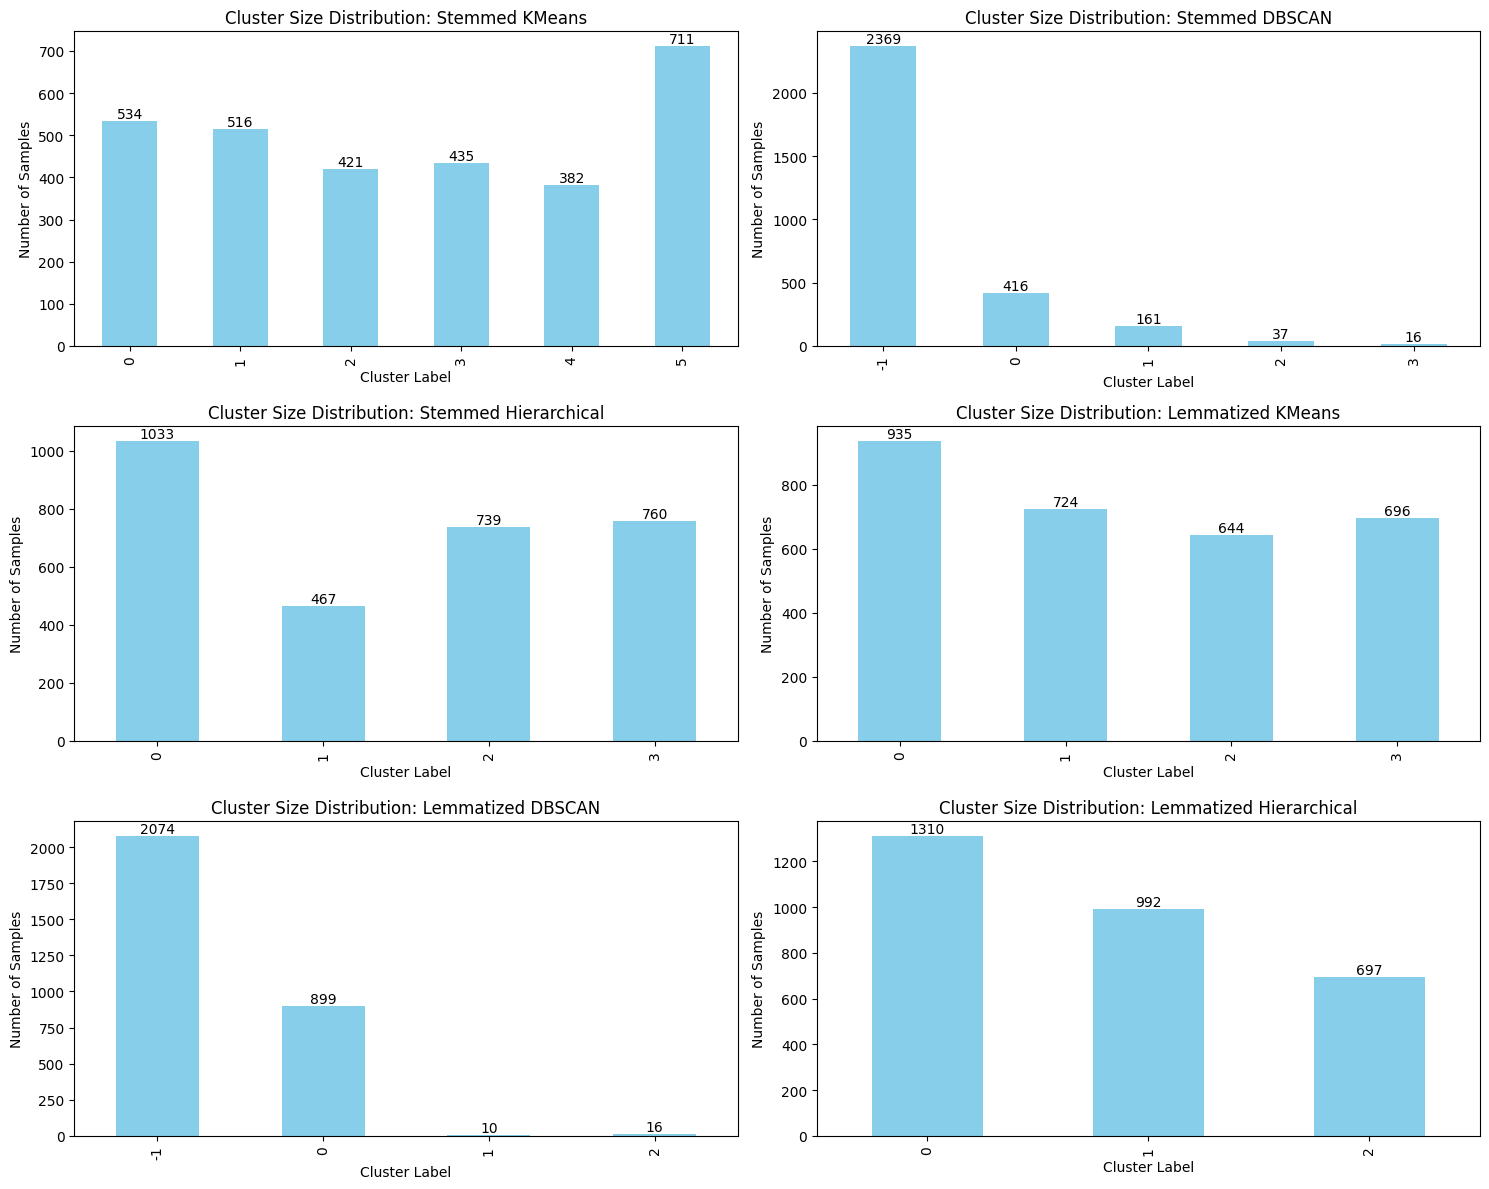

In [53]:
cluster_columns = [
    'stemmed_kmeans_cluster',
    'stemmed_dbscan_cluster',
    'stemmed_hierarchical_cluster',
    'lemmatized_kmeans_cluster',
    'lemmatized_dbscan_cluster',
    'lemmatized_hierarchical_cluster'
]

titles = [
    'Stemmed KMeans',
    'Stemmed DBSCAN',
    'Stemmed Hierarchical',
    'Lemmatized KMeans',
    'Lemmatized DBSCAN',
    'Lemmatized Hierarchical'
]

plt.figure(figsize=(15, 12))

for i, col in enumerate(cluster_columns):
    plt.subplot(3, 2, i+1)
    counts = music_df[col].value_counts().sort_index()
    counts.plot(kind='bar', color='skyblue')
    plt.title(f'Cluster Size Distribution: {titles[i]}')
    plt.xlabel('Cluster Label')
    plt.ylabel('Number of Samples')

    for idx, val in enumerate(counts):
        plt.text(idx, val + max(counts)*0.01, str(val), ha='center')

plt.tight_layout()
plt.show()


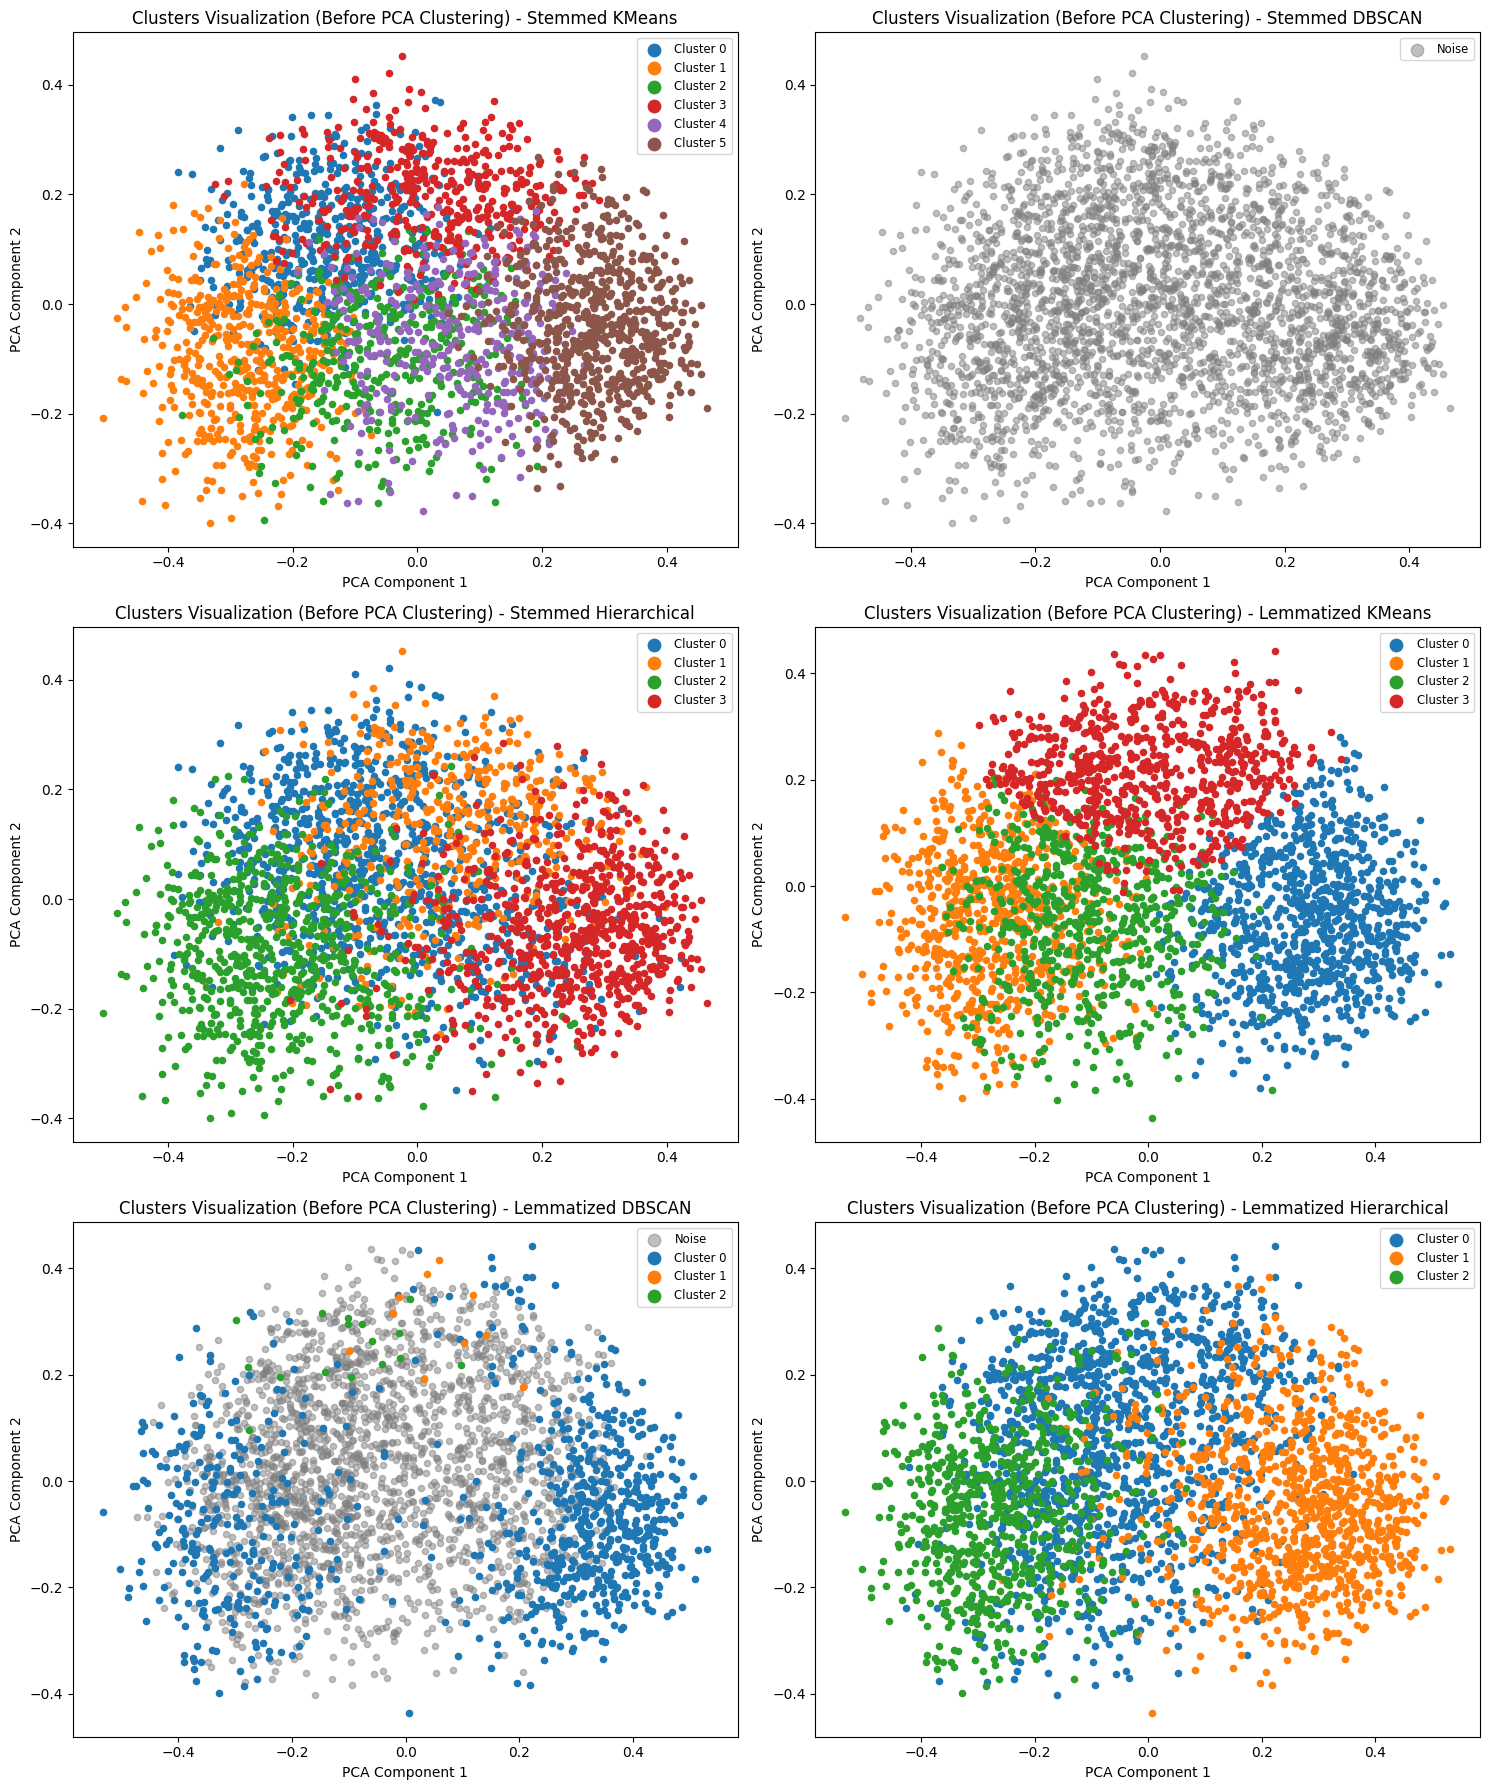

In [61]:
pca_2d = PCA(n_components=2)
stemmed_2d = pca_2d.fit_transform(stemmed_embeddings)
lemmatized_2d = pca_2d.fit_transform(lemmatized_embeddings)

methods = [
    ('stemmed_kmeans_cluster', stemmed_2d, 'Stemmed KMeans'),
    ('stemmed_dbscan_cluster', stemmed_2d, 'Stemmed DBSCAN'),
    ('stemmed_hierarchical_cluster', stemmed_2d, 'Stemmed Hierarchical'),
    ('lemmatized_kmeans_cluster', lemmatized_2d, 'Lemmatized KMeans'),
    ('lemmatized_dbscan_cluster', lemmatized_2d, 'Lemmatized DBSCAN'),
    ('lemmatized_hierarchical_cluster', lemmatized_2d, 'Lemmatized Hierarchical')
]

plt.figure(figsize=(15, 18))

for i, (col, embeddings_2d, title) in enumerate(methods, 1):
    plt.subplot(3, 2, i)
    clusters = music_df[col]
    
    unique_clusters = sorted(set(clusters))
    
    for cluster in unique_clusters:
        mask = clusters == cluster
        if cluster == -1:
            plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], label='Noise', alpha=0.5, s=20, color='gray')
        else:
            plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], label=f'Cluster {cluster}', s=20)
    
    plt.title(f'Clusters Visualization (Before PCA Clustering) - {title}')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(loc='best', fontsize='small', markerscale=2)

plt.tight_layout()
plt.show()


    Supervised vs. Unsupervised Learning:

Supervised learning is a type of machine learning where the model is trained on labeled data — meaning each input comes with a known output. The model uses the input-output pairs to learn patterns and make predictions on new, unseen data. It is more accurate if enough labeled data is available and can directly measure performance. But it requires large labeled datasets and labeling can be expensive. 

Unsupervised learning works with unlabeled data, where the model tries to discover hidden patterns or groupings within the data. The model analyzes similarities or statistical properties to group or reduce data. No need for labeled data and useful for pattern discovery. But results are harder to evaluate and clusters may not always align with meaningful categories.

    Reason for Using Feature Vectors

Feature vectors convert raw text into numerical form that machine learning models can understand. They capture important information like word frequency or meaning, enabling models to detect patterns, classify, or cluster text effectively.


    Feature Vectorization Methods

1. Bag Of Words (BOW):

Counts how many times each word appears in the text. Simple but ignores word order and meaning.

2. TF-IDF:

Like BoW but gives less weight to common words across all documents, highlighting important words. BUt still ignores word order and semantics.


3. Word Embeddings(Word2Vec, GloVe):

Represents words as dense vectors capturing their meanings and relationships. It captures meaning and word similarity, but requires lots of training data.

4. Contextual Embeddings (BERT, GPT):

Generates word vectors that change depending on the context, providing a more accurate understanding. It requires large models and resources.



---

***Reduce***

Principal Component Analysis (PCA):

PCA is a dimensionality reduction technique that transforms possibly correlated variables into a smaller number of uncorrelated variables called principal components. It finds new components that capture the maximum variance in the data. These components are linear combinations of the original variables. Then selects the top components that explain most of the variance to reduce data dimensions with minimal information loss.

In [29]:
pca_stemmed = PCA(n_components=0.95)
stemmed_pca = pca_stemmed.fit_transform(stemmed_embeddings)

pca_lemmatized = PCA(n_components=0.95)
lemmatized_pca = pca_lemmatized.fit_transform(lemmatized_embeddings)

     K-Means + Elbow Method

- For stemmed embedding:

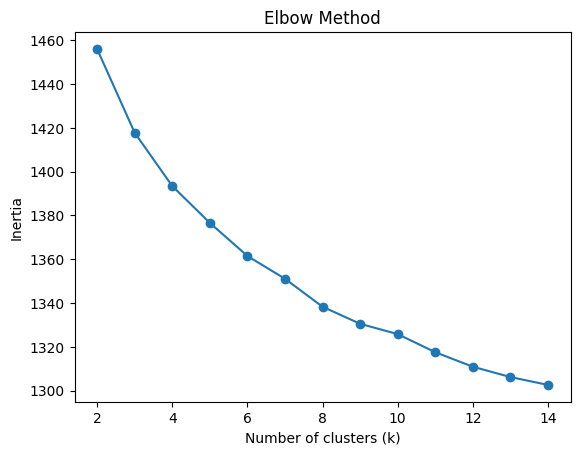

In [30]:
inertia = []
k_range = range(2, 15)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(stemmed_pca)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

we choose K = 5 based on plot.

In [33]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=0)
music_df['stemmed_kmeans_cluster_pca'] = kmeans.fit_predict(stemmed_pca)

- For lemmatized embedding:

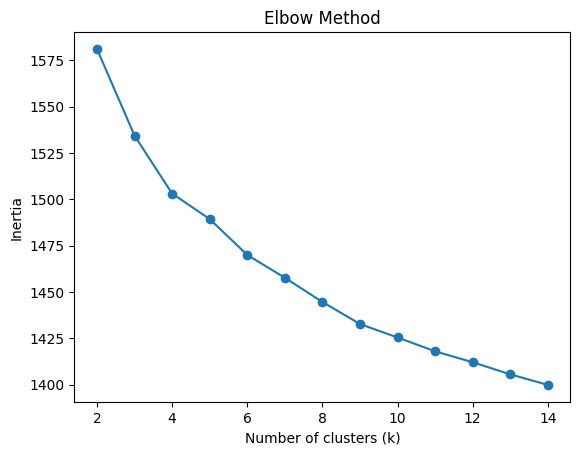

In [32]:
inertia = []
k_range = range(2, 15)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(lemmatized_pca)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

We choose K = 4.

In [34]:
K = 4 
kmeans = KMeans(n_clusters=K, random_state=0)
music_df['lemmatized_kmeans_cluster_pca'] = kmeans.fit_predict(lemmatized_pca)

    DBSCAN

- For stemmed embedding:

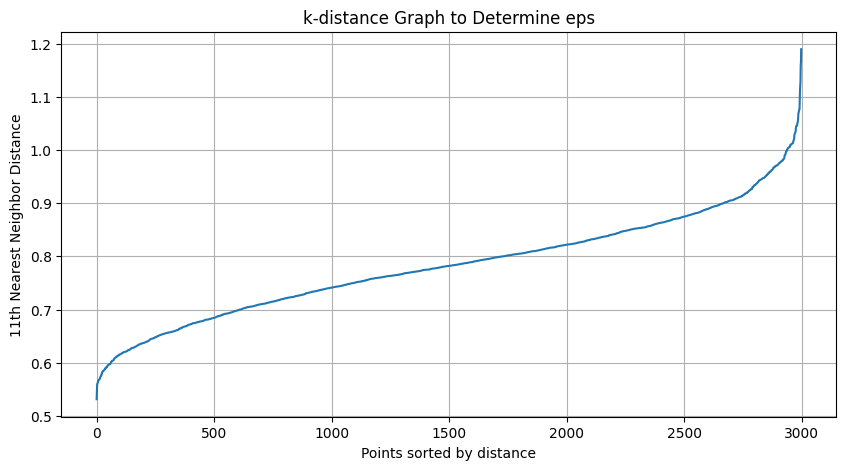

In [65]:
k = 11
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(stemmed_pca)
distances, indices = nbrs.kneighbors(stemmed_pca)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.ylabel(f"{k}th Nearest Neighbor Distance")
plt.xlabel("Points sorted by distance")
plt.title("k-distance Graph to Determine eps")
plt.grid(True)
plt.show()

The eps based on this plot should be near to 0.9, but it doesn't work well, so I find proper eps manually.

In [80]:
dbscan = DBSCAN(eps=0.56, min_samples=12, metric='cosine', algorithm='brute', n_jobs=-1)
music_df['stemmed_dbscan_cluster_pca'] = dbscan.fit_predict(stemmed_pca)

- For lemmatized embedding:

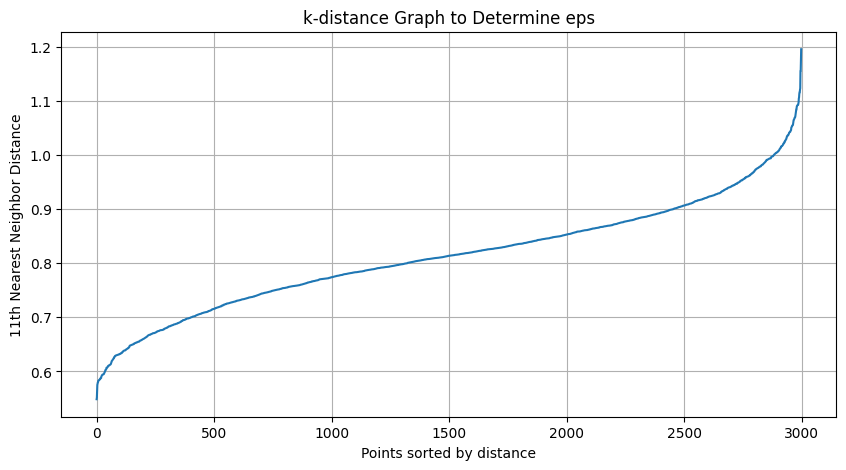

In [69]:
k = 11
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(lemmatized_pca)
distances, indices = nbrs.kneighbors(lemmatized_pca)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.ylabel(f"{k}th Nearest Neighbor Distance")
plt.xlabel("Points sorted by distance")
plt.title("k-distance Graph to Determine eps")
plt.grid(True)
plt.show()

The eps based on this plot should be near to 1, but it doesn't work well, so I find proper eps manually.

In [79]:
dbscan = DBSCAN(eps=0.56, min_samples=12, metric='cosine', algorithm='brute', n_jobs=-1)
music_df['lemmatized_dbscan_cluster_pca'] = dbscan.fit_predict(lemmatized_pca)

    Hierarchical Clustering

- For stemmed embedding:

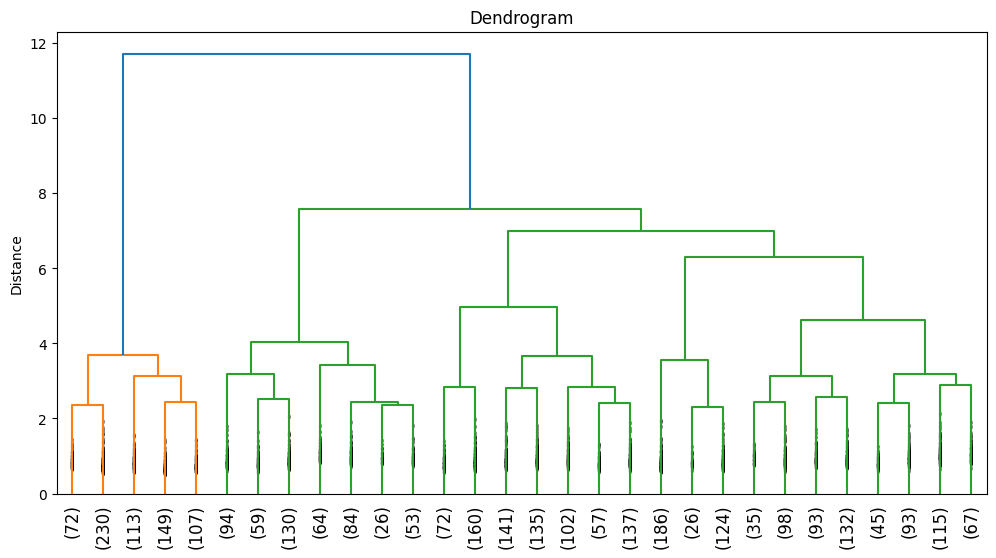

In [71]:
linked = linkage(stemmed_pca, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=12., show_contracted=True)
plt.title('Dendrogram')
plt.ylabel('Distance')
plt.show()

We choose num of cluster = 3 based on denogram.

In [88]:
agg = AgglomerativeClustering(n_clusters= 3)
music_df['stemmed_hierarchical_cluster_pca'] = agg.fit_predict(stemmed_pca)

- For lemmatized embedding:

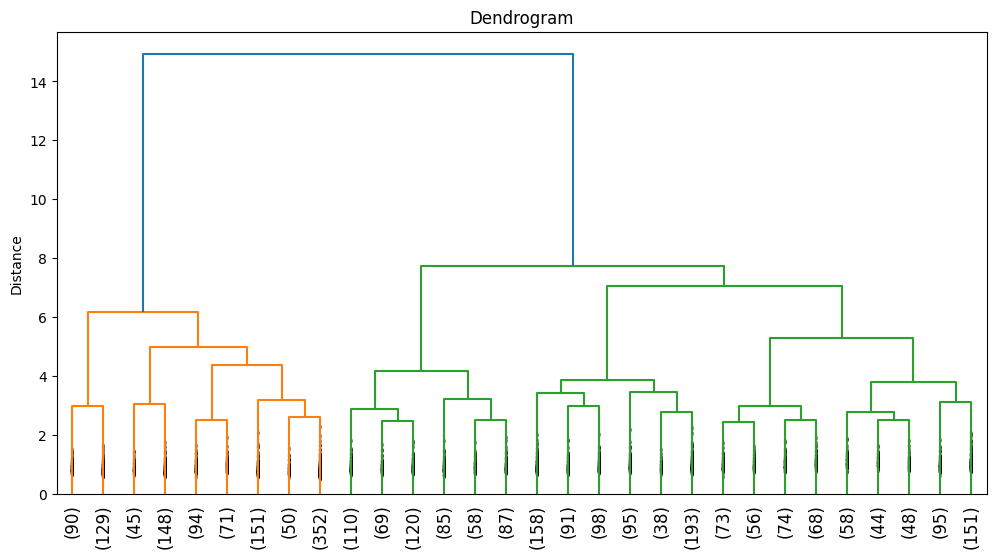

In [73]:
linked = linkage(lemmatized_pca, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=12., show_contracted=True)
plt.title('Dendrogram')
plt.ylabel('Distance')
plt.show()

We choose num of cluster = 3 based on denogram.

In [75]:
agg = AgglomerativeClustering(n_clusters= 3)
music_df['lemmatized_hierarchical_cluster_pca'] = agg.fit_predict(lemmatized_pca)

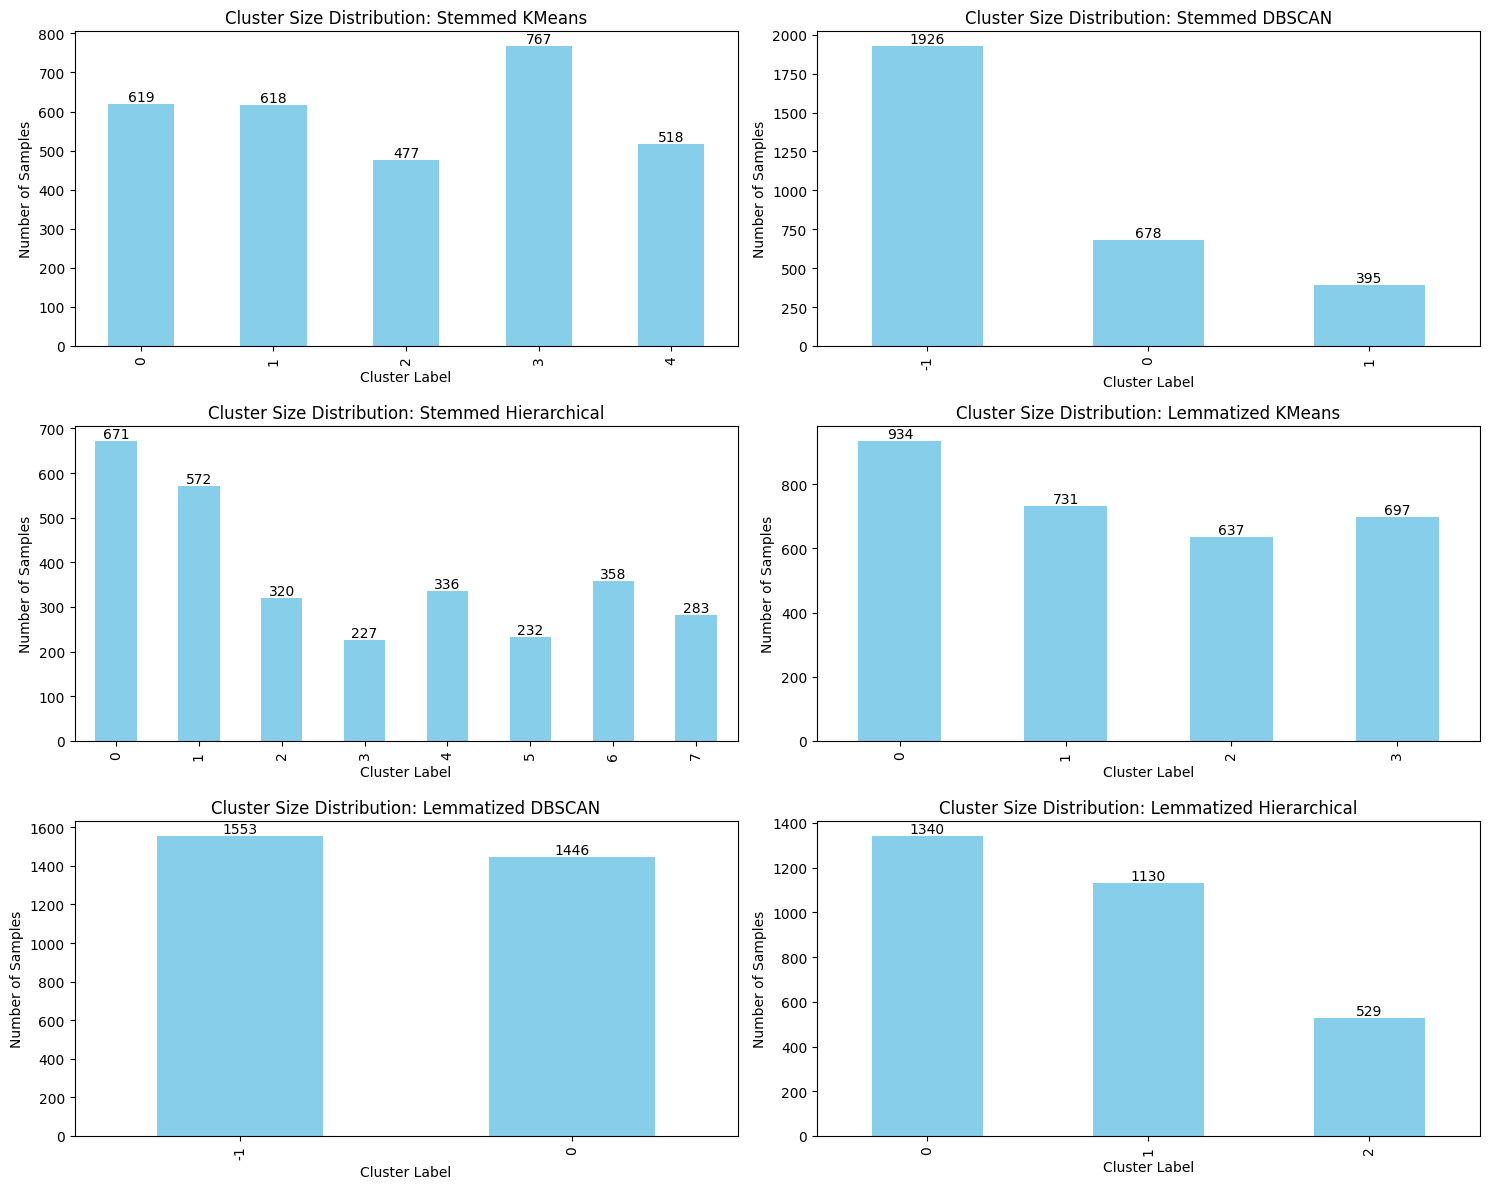

In [86]:
cluster_columns = [
    'stemmed_kmeans_cluster_pca',
    'stemmed_dbscan_cluster_pca',
    'stemmed_hierarchical_cluster_pca',
    'lemmatized_kmeans_cluster_pca',
    'lemmatized_dbscan_cluster_pca',
    'lemmatized_hierarchical_cluster_pca'
]

titles = [
    'Stemmed KMeans',
    'Stemmed DBSCAN',
    'Stemmed Hierarchical',
    'Lemmatized KMeans',
    'Lemmatized DBSCAN',
    'Lemmatized Hierarchical'
]

plt.figure(figsize=(15, 12))

for i, col in enumerate(cluster_columns):
    plt.subplot(3, 2, i+1)
    counts = music_df[col].value_counts().sort_index()
    counts.plot(kind='bar', color='skyblue')
    plt.title(f'Cluster Size Distribution: {titles[i]}')
    plt.xlabel('Cluster Label')
    plt.ylabel('Number of Samples')

    for idx, val in enumerate(counts):
        plt.text(idx, val + max(counts)*0.01, str(val), ha='center')

plt.tight_layout()
plt.show()


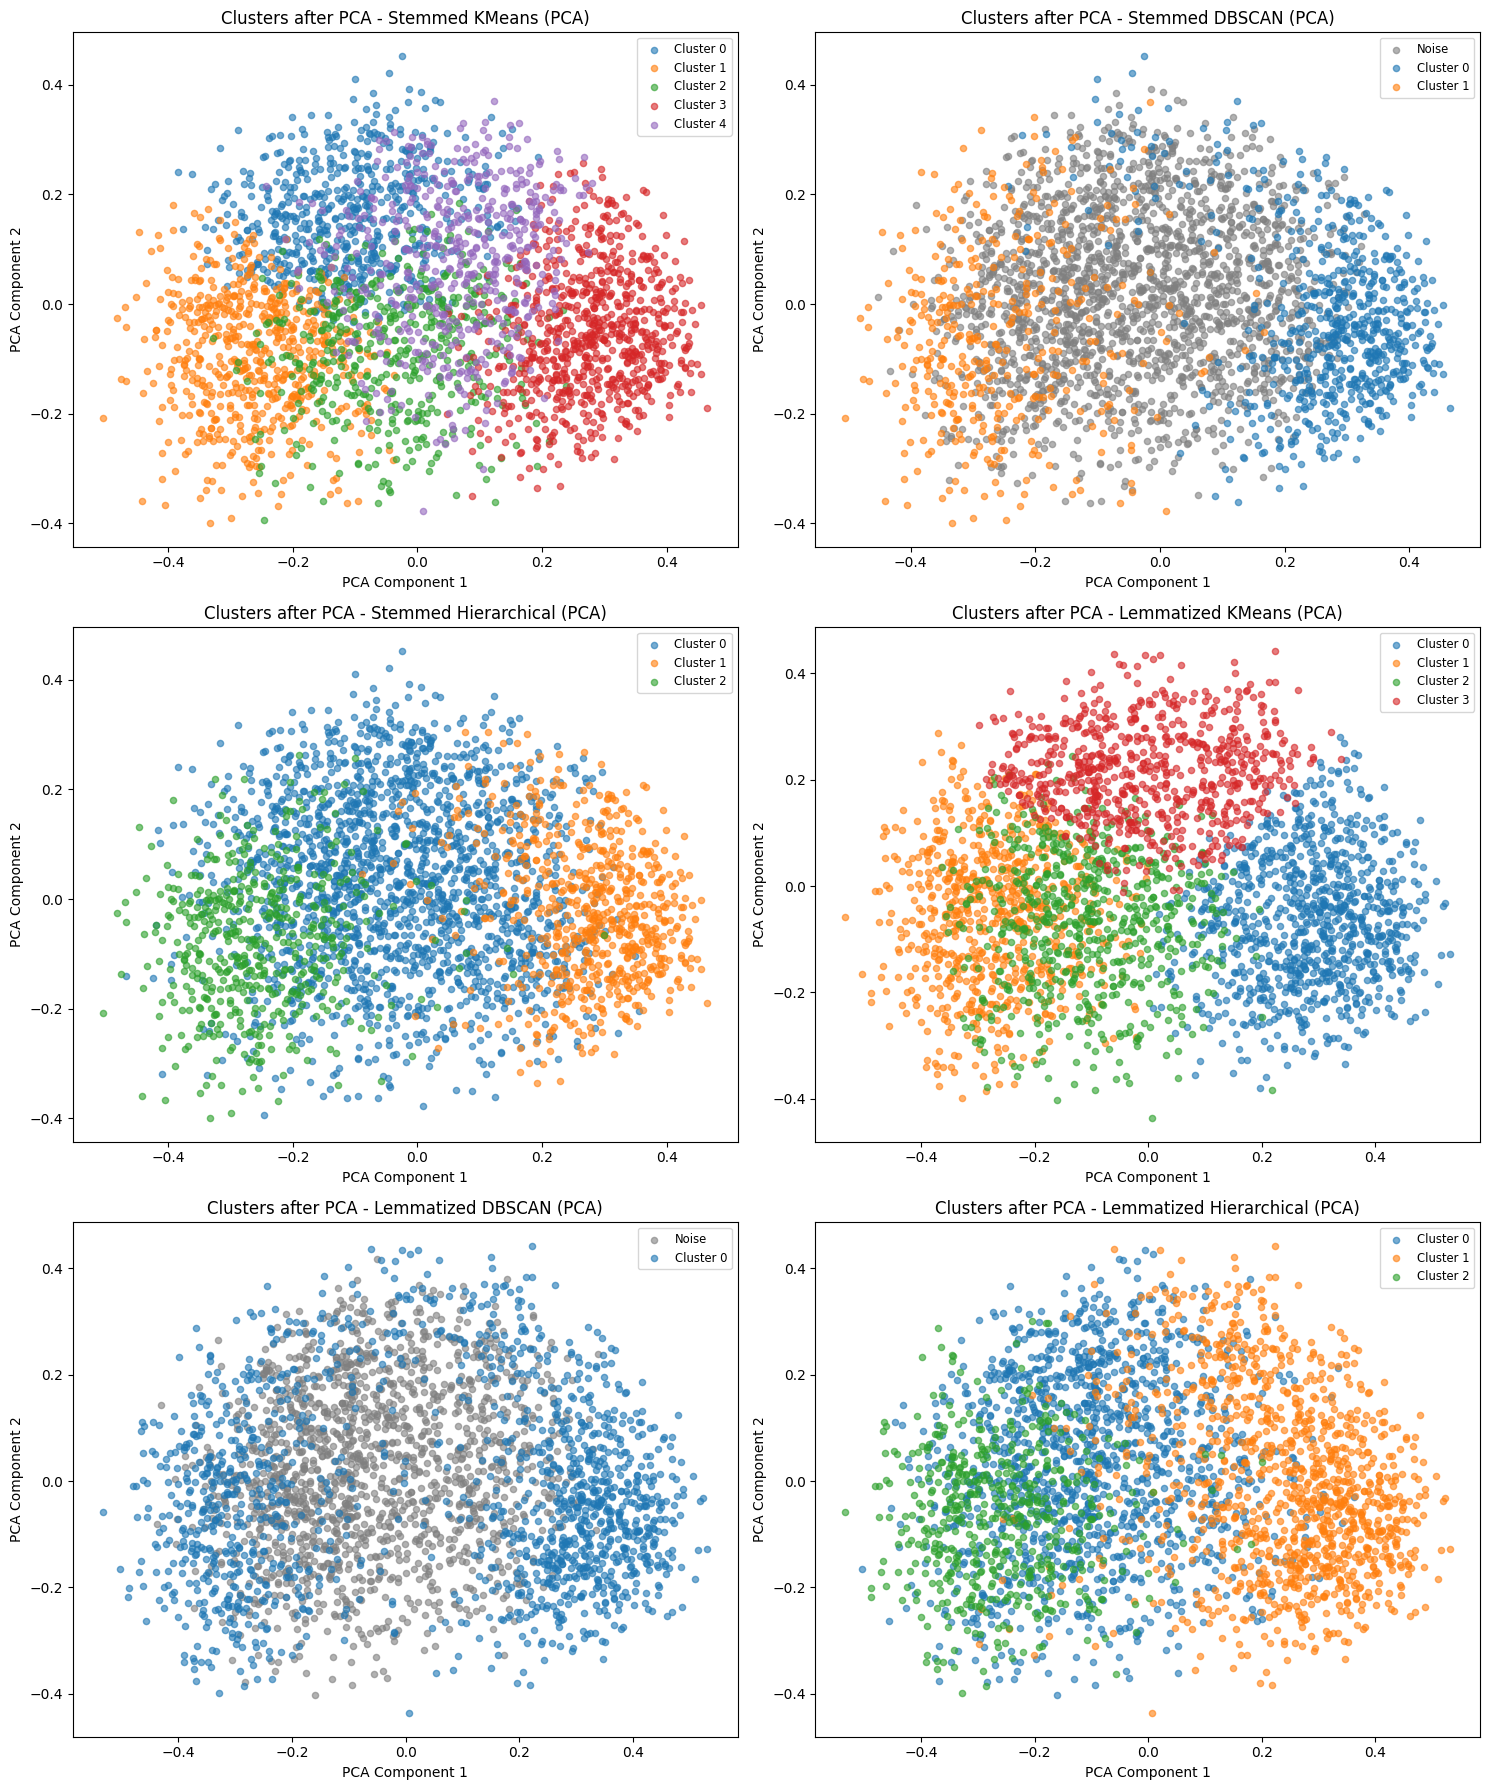

In [89]:
stemmed_pca_2d = PCA(n_components=2).fit_transform(stemmed_pca)
lemmatized_pca_2d = PCA(n_components=2).fit_transform(lemmatized_pca)

methods = [
    ('stemmed_kmeans_cluster_pca', stemmed_pca_2d, 'Stemmed KMeans (PCA)'),
    ('stemmed_dbscan_cluster_pca', stemmed_pca_2d, 'Stemmed DBSCAN (PCA)'),
    ('stemmed_hierarchical_cluster_pca', stemmed_pca_2d, 'Stemmed Hierarchical (PCA)'),
    ('lemmatized_kmeans_cluster_pca', lemmatized_pca_2d, 'Lemmatized KMeans (PCA)'),
    ('lemmatized_dbscan_cluster_pca', lemmatized_pca_2d, 'Lemmatized DBSCAN (PCA)'),
    ('lemmatized_hierarchical_cluster_pca', lemmatized_pca_2d, 'Lemmatized Hierarchical (PCA)')
]

plt.figure(figsize=(15, 18))

for i, (col, embeddings_2d, title) in enumerate(methods, 1):
    plt.subplot(3, 2, i)
    clusters = music_df[col]
    unique_clusters = sorted(set(clusters))

    for cluster in unique_clusters:
        mask = clusters == cluster
        color = 'gray' if cluster == -1 else None
        label = 'Noise' if cluster == -1 else f'Cluster {cluster}'
        plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], label=label, s=20, alpha=0.6, color=color)

    plt.title(f'Clusters after PCA - {title}')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(loc='best', fontsize='small')

plt.tight_layout()
plt.show()


---

***Compare and choose perfect method***

In [83]:
silhouette_scores_pca = {}

def evaluate_silhouette(embeddings, labels, name):
    if len(set(labels)) > 1 and len(set(labels)) < len(labels):
        score = silhouette_score(embeddings, labels)
        print(f'{name} Silhouette Score: {score:.4f}')
        return score
    else:
        print(f'{name} Silhouette Score: Not applicable')
        return None

def evaluate_clustering(silhouette_scores, embeddings, labels, method_name=''):
    if len(set(labels)) > 1 and len(set(labels)) < len(labels):
        sil_score = silhouette_score(embeddings, labels)
        silhouette_scores[method_name] = sil_score
        print(f"{method_name} - Silhouette Score: {sil_score:.4f}")
    else:
        silhouette_scores[method_name] = None
        print(f"{method_name} - Silhouette Score: Not applicable")

silhouette_scores_pca['Stemmed KMeans'] = evaluate_silhouette(stemmed_pca, music_df['stemmed_kmeans_cluster_pca'], 'Stemmed KMeans (PCA)')
silhouette_scores_pca['Stemmed DBSCAN'] = evaluate_silhouette(stemmed_pca, music_df['stemmed_dbscan_cluster_pca'], 'Stemmed DBSCAN (PCA)')
silhouette_scores_pca['Stemmed Hierarchical'] = evaluate_silhouette(stemmed_pca, music_df['stemmed_hierarchical_cluster_pca'], 'Stemmed Hierarchical (PCA)')

silhouette_scores_pca['Lemmatized KMeans'] = evaluate_silhouette(lemmatized_pca, music_df['lemmatized_kmeans_cluster_pca'], 'Lemmatized KMeans (PCA)')
silhouette_scores_pca['Lemmatized DBSCAN'] = evaluate_silhouette(lemmatized_pca, music_df['lemmatized_dbscan_cluster_pca'], 'Lemmatized DBSCAN (PCA)')
silhouette_scores_pca['Lemmatized Hierarchical'] = evaluate_silhouette(lemmatized_pca, music_df['lemmatized_hierarchical_cluster_pca'], 'Lemmatized Hierarchical (PCA)')


Stemmed KMeans (PCA) Silhouette Score: 0.0255
Stemmed DBSCAN (PCA) Silhouette Score: 0.0093
Stemmed Hierarchical (PCA) Silhouette Score: 0.0137
Lemmatized KMeans (PCA) Silhouette Score: 0.0515
Lemmatized DBSCAN (PCA) Silhouette Score: 0.0165
Lemmatized Hierarchical (PCA) Silhouette Score: 0.0461


Best method overall: Lemmatized KMeans after PCA

Sample Lyrics from Each Cluster (Lemmatized KMeans):

In [84]:
lemm_kmeans_clusters_pca = music_df.groupby('lemmatized_kmeans_cluster_pca')
print_sample(lemm_kmeans_clusters )


Cluster 0

Sample 1:
[Verse 1 Kano] Ah, Twentyfour seven Im on this Viagra flow hardest for the longest Niagra flow pass this at your own risk Aha their not finding the Kane But the flows like herpes never go away Creps l ...

Sample 2:
I look into your face No flaws I cant see a trace You the electricity to my heart Whenever I feel down you give me a jump start When your lips leave mine my mouth feels tart So Im going to ask you to  ...

Cluster 1

Sample 1:
My eyes are open, Though Im inside a dream Im laying on the bed, But my soul is running I feel the burning sweat covering my body. My heart beats as hell I cant catch my breath Im waiting for the days ...

Sample 2:
life is a long lived torment haunted by our useless existence the world will still keep decaying when were all in our grave depression live is morbid hell precious? I think not who cares about the fel ...

Cluster 2

Sample 1:
The bus north was a rumbling gray coffin, evidence of my failure, like a tamed and crippled 

---

    Silhouette Score

Measures how similar each data point is to its own cluster compared to other clusters. The range is from -1 to 1, where values closer to 1 indicate better-defined clusters. It Calculates the average distance between a point and all other points in its cluster (a). Then calculates the average distance between that point and points in the nearest other cluster (b).

Silhouette score = (b - a) / max(a, b).

    Homogeneity

Measures how much each cluster contains only members of a single class. The range is between 0 and 1, where 1 means each cluster contains data points from only one class. Requires the availability of true class labels to compare the clustering result against the ground truth.

Why Homogeneity Cannot Be Used in This Project?

Homogeneity is a clustering evaluation metric that requires true labels or categories for each data point (genre labels like pop,rock,..). It measures how well the clustering matches those real categories. We do not have true labels for the lyrics. 